# Analysis of Variance Using the NBA Draft - Sample Solutions

## Introduction

Each year, the National Basketball Association (NBA) holds a draft, where prospective basketball players are able to be chosen to join one of the 30 professional teams across the United States and Canada.

In order to be eligible for the draft, a player must be at least 19 years old and out of high school for at least one year. Prior to 2006, this rule was not in effect, and players could be drafted during or right out of high school.

The draft is comprised of 60 players and takes place over two rounds of 30 selections. Teams pick players in an order based on performance from the previous season, with teams that performed poorly getting earlier picks in order to create a seemingly more level playing field. It is important to note that there were not always 30 players selected in each round; the number made its way up to 30 as more teams were added into the NBA.

The data you will be using comes from the dataset `nba_draft.csv` and focuses on players who were selected in the first round of the NBA Draft between 1990 and 2021. For each player, the dataset includes a range of career statistics from their time in the NBA. Some players' careers are still ongoing, but in this activity we will focus on the average number of minutes they have played per game.

Analyzing minutes per game is useful because it measures how much playing time a player earned during their NBA career, which is one indicator of a player's role and value to a team. However, minutes per game is not a perfect measure of player quality because playing time can also be influenced by team expectations, injuries, roster needs, coaching decisions, and the opportunity given to high draft picks.

In this activity, we will investigate whether NBA players selected earlier in the first round tend to have different average career minutes per game than players selected later in the first round. To do this, we will compare three groups of first-round picks: picks 1--10, picks 11--20, and picks 21--30.


## Setup

The code below loads the libraries used in this activity and reads in the data.

In [14]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
from plotnine import (
    ggplot,
    aes,
    geom_density,
    geom_vline,
    geom_boxplot,
    labs,
    theme_minimal,
    theme,
    element_text
)


In [15]:
nba_draft = pd.read_csv("nba_draft.csv")
nba_draft.head()


,pick_overall,team,player_name,college,years_played,games_played,total_mins_played,total_pts,total_rebounds,total_assists,...,win_shares,win_shares_per_48,draft_year,mins_per_game,pts_per_game,rebounds_per_game,assists_per_game,round_picked,pick_in_round,draft_pick_group
0,1,BRK,Derrick Coleman,Syracuse,15,781,25903,12884,7232,1985,...,64.3,0.119,1990,33.2,16.5,9.3,2.5,1,1,Picks 1-10
1,2,OKC,Gary Payton,Oregon State,17,1335,47117,21813,5269,8966,...,145.5,0.148,1990,35.3,16.3,3.9,6.7,1,2,Picks 1-10
2,3,DEN,Mahmoud Abdul-Rauf,LSU,9,586,15628,8553,1087,2079,...,25.2,0.077,1990,26.7,14.6,1.9,3.5,1,3,Picks 1-10
3,4,ORL,Dennis Scott,Georgia Tech,10,629,17983,8094,1774,1296,...,33.4,0.089,1990,28.6,12.9,2.8,2.1,1,4,Picks 1-10
4,5,CHA,Kendall Gill,Illinois,15,966,29481,12914,4002,2945,...,47.8,0.078,1990,30.5,13.4,4.1,3.0,1,5,Picks 1-10


## Visualizing the Distributions

Create overlapping density plots that show the distribution of minutes per game for each group. Add dashed vertical lines representing the group means.


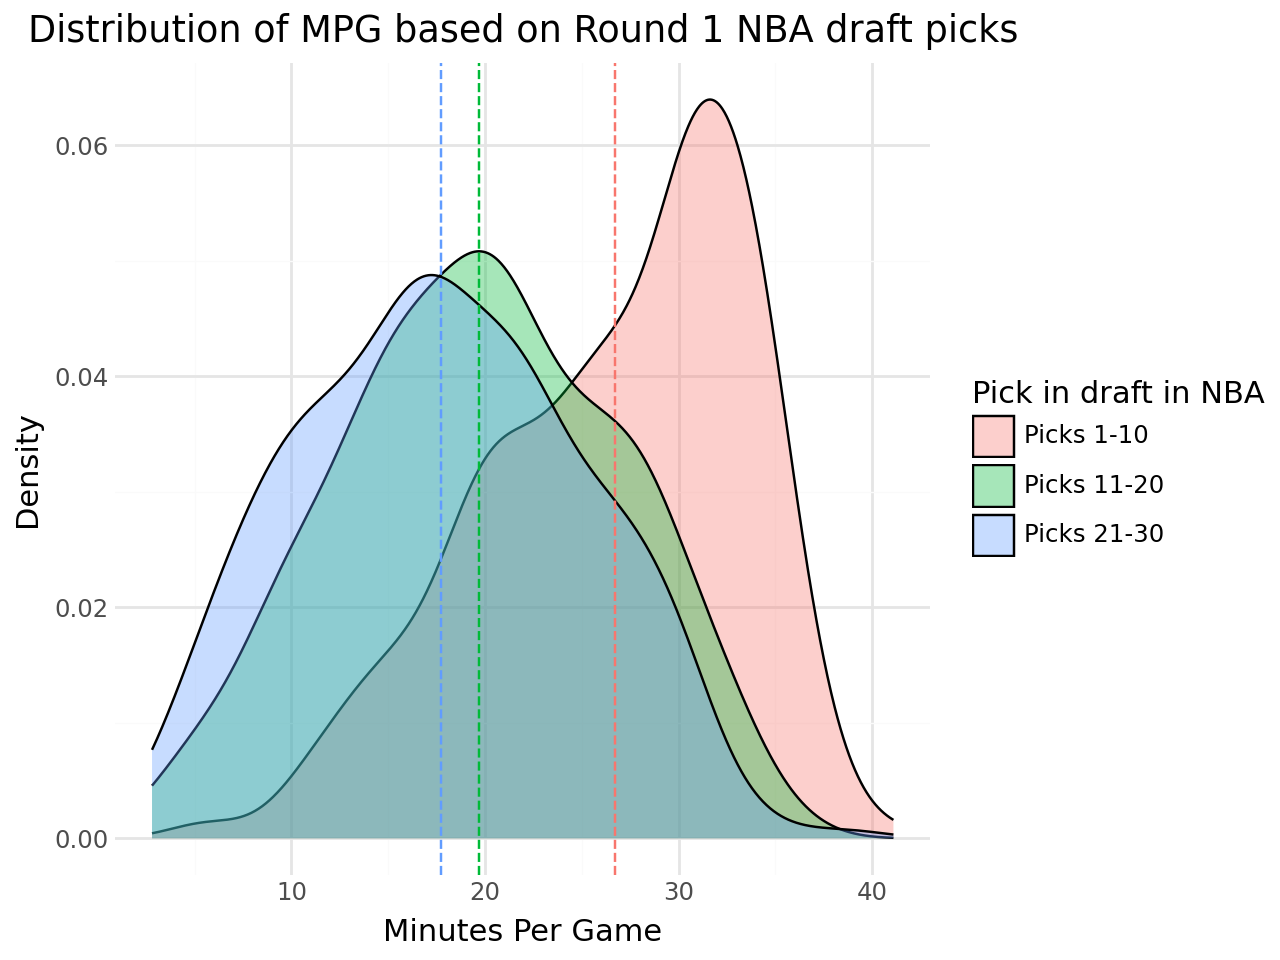

In [16]:
group_means = (
    nba_draft
    .groupby("draft_pick_group", observed=True, as_index=False)["mins_per_game"]
    .mean()
)

(
    ggplot(nba_draft, aes(x="mins_per_game", fill="draft_pick_group"))
    + geom_density(alpha=0.35)
    + geom_vline(
        group_means,
        aes(xintercept="mins_per_game", color="draft_pick_group"),
        linetype="dashed",
        show_legend=False
    )
    + labs(
        title="Distribution of MPG based on Round 1 NBA draft picks",
        x="Minutes Per Game",
        y="Density",
        fill="Pick in draft in NBA"
    )
    + theme_minimal()
)


Now create side-by-side boxplots that show the distribution of minutes per game for each group.


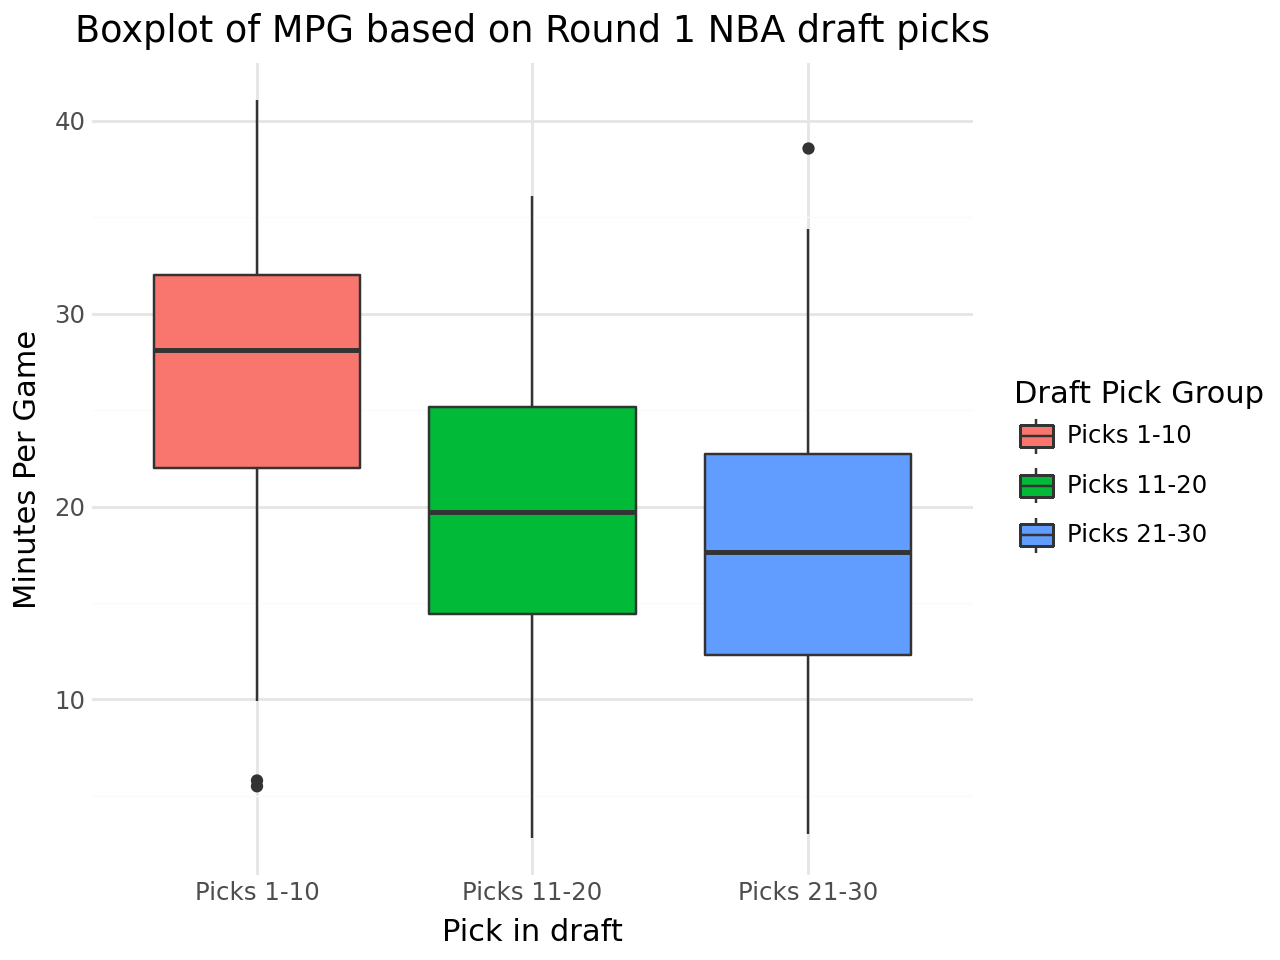

In [18]:
(
    ggplot(nba_draft, aes(x="draft_pick_group", y="mins_per_game", fill = "draft_pick_group"))
    + geom_boxplot()
    + labs(
        title="Boxplot of MPG based on Round 1 NBA draft picks",
        x="Pick in draft",
        y="Minutes Per Game",
        fill = "Draft Pick Group"
    )
    + theme_minimal()
    + theme(axis_text_x=element_text(rotation=0))
)


## Questions

### 1. Visual comparison

Based on the density plot and side-by-side boxplots, what do you notice about the distributions of minutes per game for the three draft-pick groups? What conclusions can you draw from a first glance at the two data visualizations? Are there any concerns?

<details>
<summary><strong>Solution</strong></summary>

The players selected with picks 1--10 appear to have the highest typical minutes per game, while players selected with picks 21--30 appear to have the lowest typical minutes per game. The picks 11--20 group appears to fall between the other two groups. The density plots and boxplots suggest that average minutes per game may decrease as draft position gets later in the first round.

The spreads of the three groups appear somewhat similar, although there is still variation within each group. There may be a few low-minute or high-minute players in each group, but there do not appear to be extreme outliers that completely dominate the plots.

</details>


### 2. Conditions for one-way ANOVA

Suppose someone suggests using a one-way ANOVA to compare average minutes per game across the three draft-pick groups. Do the conditions for one-way ANOVA appear reasonable for these data? Explain your answer by discussing both the data source and the graphical displays.

<details>
<summary><strong>Solution</strong></summary>

A one-way ANOVA appears reasonable for these data, but there are some conditions to consider:

- **Quantitative response variable:** Minutes per game is a quantitative variable suitable for the response in ANOVA.

- **Categorical explanatory variable with independent groups:** The explanatory variable is draft-pick group, which is categorical with three non-overlapping groups. Each player appears only once in one of the three groups.

- **Approximately normal sampling distribution for the sample mean:** The density plots do not look perfectly normal, but the sample sizes are large for each draft-pick group. Because of this, the sampling distributions of the sample means should be approximately normal by the Central Limit Theorem. There do not appear to be extreme outliers that would completely dominate the analysis.

- **Approximately same standard deviations:** The side-by-side boxplots and the group summaries suggest that the spreads of minutes per game are reasonably similar across the three draft-pick groups.

- **Biggest potential concern: random sample / randomization:** These data come from first-round NBA draft picks from 1990--2021, not from a random sample or randomized experiment. Because of this, we should be cautious about generalizing too broadly beyond players and draft years similar to those in this dataset. It is worth noting that a random sample is also not especially feasible here, so this can be a useful applied-statistics example of working carefully with the available data.

Overall, using one-way ANOVA seems reasonable, but the results should be interpreted with some caution because the data are observational and minutes per game is influenced by factors beyond just a player's ability.

</details>


### 3. Hypotheses

Regardless of your answer to the previous question, write the null and alternative hypotheses for testing whether average career minutes per game differs among the three draft-pick groups. Use standard notation and also interpret each hypothesis in context.

<details>
<summary><strong>Solution</strong></summary>

Let:

- $\mu_{1-10}$ be the population mean career minutes per game for players selected with picks 1--10.
- $\mu_{11-20}$ be the population mean career minutes per game for players selected with picks 11--20.
- $\mu_{21-30}$ be the population mean career minutes per game for players selected with picks 21--30.

**Null hypothesis:**

$$
H_0: \mu_{1-10} = \mu_{11-20} = \mu_{21-30}
$$

In context, the population mean career minutes per game is the same for players selected with picks 1--10, picks 11--20, and picks 21--30 in the first round of the NBA Draft.

**Alternative hypothesis:**

$$
H_a: \text{At least one of the population means is different.}
$$

In context, at least one draft-pick group has a different population mean career minutes per game than the others.

</details>


### 4. ANOVA output

Use Python to conduct the one-way ANOVA for comparing mean career minutes per game across the three draft-pick groups. The code below uses `statsmodels`, which plays a role similar to `aov()` in R: fit the model first, then request the ANOVA table.


In [ ]:
anova_model = ols("mins_per_game ~ C(draft_pick_group)", data=nba_draft).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
anova_table


### 5. ANOVA conclusion

Based on the ANOVA table, is there statistically significant evidence that mean career minutes per game differs among the three draft-pick groups? Explain your conclusion in context.

<details>
<summary><strong>Solution</strong></summary>

Since the p-value is less than 0.001, we reject the null hypothesis. There is strong statistical evidence that mean career minutes per game differs among the three first-round draft-pick groups: picks 1--10, picks 11--20, and picks 21--30.

*This does not tell us which specific groups differ from each other; it only tells us that at least one group mean is different.*

</details>


### 6. Comparing the group means

Based on the plots and group means, which two draft-pick groups appear to differ the most in average career minutes per game? Which two groups appear to differ the least? Provide evidence.

<details>
<summary><strong>Solution</strong></summary>

The groups that appear to differ the most are players selected with picks 1--10 and players selected with picks 21--30, because these groups have the largest difference in mean minutes per game. Players selected with picks 1--10 tend to have higher career minutes per game, while players selected with picks 21--30 tend to have lower career minutes per game.

The groups that appear to differ the least are players selected with picks 11--20 and picks 21--30, because their group means are closest together. The density plot and side-by-side boxplots also show more overlap between these two groups than between picks 1--10 and picks 21--30.

*This comparison is based on the plots and group means, not a separate formal test for each pair of groups.*

</details>


### 7. Interpreting minutes per game

Minutes per game is useful, but it is not a perfect measure of player quality. Explain one reason why players selected earlier in the draft might have higher career minutes per game even if draft position does not perfectly measure player ability.

<details>
<summary><strong>Solution</strong></summary>

Players selected earlier in the draft may receive more playing time because teams have invested more in them and may want to give them more opportunities to develop. In the NBA, coaches decide how many minutes each player gets in a game, and those decisions can be influenced by performance, injuries, team strategy, roster depth, and expectations for player development. Because of this, differences in minutes per game may reflect both player ability and opportunity.

**Instructor note:** If students are unfamiliar with the NBA, it may help to explain that playing time is not automatically assigned. Coaches choose how many minutes each player receives, and high draft picks may be given more opportunities because teams have invested more in them, expect them to become important players, or simply do not have better options available to them.

</details>


### 8. Improving the analysis

The draft-pick groups used in this activity, picks 1--10, 11--20, and 21--30, were chosen by the analyst. While this may be one reasonable way to divide the first round, it is not the only option. Propose one different way to group the players or one different variable to analyze if you wanted to better understand the relationship between draft position and NBA career success. Explain why your choice might change or improve the analysis.

<details>
<summary><strong>Solution</strong></summary>

*Answers will vary and are likely based on how knowledgeable a student is about basketball.* One alternative would be to compare lottery picks to non-lottery first-round picks. Lottery picks are generally selected by teams that missed the playoffs and may be viewed as higher-investment prospects. Another alternative would be to group picks by the type of team that selected them, such as lottery teams versus playoff teams, because players drafted by weaker teams may have more immediate opportunity for playing time. These groupings might better reflect differences in team context and opportunity than simply using picks 1--10, 11--20, and 21--30.

Students might also suggest using a different response variable, such as games played, points per game, win shares, or win shares per 48 minutes. These variables may capture different aspects of NBA career success. However, each possible response variable has its own limitations, so the best analysis may require considering several measures rather than relying on only one.

</details>
